## Introduction 

In this script, the straightness per ward is computed. First, the straightness for the entire Bangalore is computed and then a loop is created where the straightness for each ward is obtained. 

## Reading in the Python libraries

In [55]:
from pathlib import Path

import geopandas as gpd
import momepy
import osmnx as ox
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm

## Loading the data

In [96]:
BASE_DIR = Path.cwd().parent
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
IMAGES_DIR = BASE_DIR / "images"
PROCESSED_DIR = DATA_DIR / "processed"
## LOGS_DIR = BASE_DIR / "logs"

path_graphml = DATA_DIR / "graphml_bang" / "bangalore_graphml.graphml"

# WARDS_GPKG_DIR = DATA_DIR / "gpkgs"
WARDS_G_DIR =  DATA_DIR / "g_files"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


In [57]:
## Detailed wards
df_inpath = PROCESSED_DIR / "bang_fix_mapshaper.shp"
print(df_inpath)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\bang_fix_mapshaper.shp


In [58]:
df = gpd.read_file(df_inpath)
df.head()

,ward_id,ward_name,Corporatio,geometry
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,..."
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13..."
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262..."
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,..."
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727..."


In [59]:
print(f'There are {df.shape[0]} wards in the dataset.')

There are 369 wards in the dataset.


Reading in the entire Bangalore network data that we had downloaded earlier as again we will "truncate" the network to the different street networks at the ward level:

In [60]:
G = ox.io.load_graphml(path_graphml)

In [61]:
G.graph["crs"]

'epsg:4326'

In [62]:
df.crs.to_epsg()

4326

## Computing street straightness at the ward level

In [63]:
results = pd.DataFrame(columns=['ward_id', 'ward_name', 'Corporatio', 'straightness'])
results

,ward_id,ward_name,Corporatio,straightness


In [64]:
## for ward in tqdm(range(0,5), desc="Processing wards"):
for ward in tqdm(range(0,len(df)), desc = "Processing wards"):

    ## print(f'Processing the {ward} ward.')

    id_ward = df['ward_id'].iloc[ward]
    name_ward = df['ward_name'].iloc[ward]
    corporation = df['Corporatio'].iloc[ward]
    
    ## print(name_ward)

    df_ward = df.iloc[[ward]]

    ## ward_geometry = df.iloc[ward,:].geometry
    ward_geometry = df_ward.geometry.iloc[0]

    ## https://docs.momepy.org/en/stable/user_guide/simple/shape.html#Street-network-shapes
    G_clipped = ox.truncate.truncate_graph_polygon(G, ward_geometry)

    streets_graph = ox.projection.project_graph(G_clipped)

    edges = ox.graph_to_gdfs(
    ox.convert.to_undirected(streets_graph),
    nodes=False,
    edges=True,
    node_geometry=False,
    fill_edge_geometry=True,
    )

    primal = momepy.gdf_to_nx(edges, approach="primal")

    primal = momepy.straightness_centrality(primal)

    nodes = momepy.nx_to_gdf(primal, lines=False)


    straightness_mean = nodes['straightness'].mean()

    ## print(straightness_mean)

    results.loc[ward] = [
        id_ward,
        name_ward,
        corporation,
        straightness_mean
    ]
    

Processing wards: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 369/369 [1:13:42<00:00, 11.98s/it]


In [65]:
results

,ward_id,ward_name,Corporatio,straightness
0,25,25 - Vinayaka Layout,West,0.722825
1,2,2 - Aerocity,North,0.644505
2,3,3 - Chowdeshwari ward,North,0.681202
3,15,15 - Ramamurthy Nagara,East,0.697888
4,58,58 - Nagashettyhalli,North,0.666402
...,...,...,...,...
364,56,56 - Gopalpura,Central,0.668262
365,57,57 - Cottonpete,Central,0.747517
366,54,54 - Binnypete,Central,0.592171
367,47,47 - IPD Salappa Ward,Central,0.714489


In [69]:
top10_highest = (
    results
    .sort_values(by='straightness', ascending=False)
    .head(10)
)
top10_highest

,Unnamed: 0,ward_id,ward_name,Corporatio,straightness
171,171,71,71 - Thimmenahalli,West,0.812208
159,159,65,65 - Manjunath Nagara,West,0.806006
190,190,102,102 - Hanumanthanagar,West,0.801283
21,21,41,41 - V.V Puram,Central,0.796102
275,275,25,25 - Ashokanagar,Central,0.792604
126,126,27,27 - Ambedkarnagar,Central,0.791497
265,265,35,35 - Hombegowda Nagara,Central,0.791483
273,273,60,60 - Seshadripuram,Central,0.791237
287,287,42,42 - Sunkenahalli,Central,0.790696
298,298,56,56 - Gayathri Nagara,West,0.787797


In [71]:
top10_lowest = (
    results
    .sort_values(by='straightness', ascending=True)
    .head(10)
)
top10_lowest

,Unnamed: 0,ward_id,ward_name,Corporatio,straightness
224,224,31,31 - Kadugodi,East,0.563037
218,218,32,32 - Channasandra,East,0.569358
208,208,49,49 - Shivanasamudra Ward,East,0.577783
195,195,9,9 - Kuvempunagara,North,0.582043
130,130,31,31 - Kasavanahalli,South,0.586229
232,232,34,34 - Kaveri Nagara,East,0.586765
348,348,94,94 - Deepanjali Nagara,West,0.588404
268,268,37,37 - BHEL Ward,Central,0.589123
147,147,64,64 - Hongasandra,South,0.591070
366,366,54,54 - Binnypete,Central,0.592171


In [66]:
print(f'The mean of the straigthness across the wards is {results["straightness"].mean()}.')
print(f'The minimum of the straigthness across the wards is {results["straightness"].min()}.')
print(f'The maximum of the straigthness across the wards is {results["straightness"].max()}.')

The mean of the straigthness across the wards is 0.6949465714379632.
The minimum of the straigthness across the wards is 0.5630365206877523.
The maximum of the straigthness across the wards is 0.8122080211013266.


In [67]:
## Save this:
results_path = PROCESSED_DIR / "results_bangalore_straightness_all_roads.csv"

results.to_csv(results_path)

In [72]:
# You can normally do things from results but I had to read them in later
results_path = PROCESSED_DIR / "results_bangalore_straightness_all_roads.csv"
results = pd.read_csv(results_path)

In [83]:
results = pd.read_csv(results_path)
results

,Unnamed: 0,ward_id,ward_name,Corporatio,straightness
0,0,25,25 - Vinayaka Layout,West,0.722825
1,1,2,2 - Aerocity,North,0.644505
2,2,3,3 - Chowdeshwari ward,North,0.681202
3,3,15,15 - Ramamurthy Nagara,East,0.697888
4,4,58,58 - Nagashettyhalli,North,0.666402
...,...,...,...,...,...
364,364,56,56 - Gopalpura,Central,0.668262
365,365,57,57 - Cottonpete,Central,0.747517
366,366,54,54 - Binnypete,Central,0.592171
367,367,47,47 - IPD Salappa Ward,Central,0.714489


In [84]:
df_merged = df.merge(results, on = 'ward_name')
df_merged

,ward_id_x,ward_name,Corporatio_x,geometry,Unnamed: 0,ward_id_y,Corporatio_y,straightness
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,...",0,25,West,0.722825
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13...",1,2,North,0.644505
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262...",2,3,North,0.681202
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,...",3,15,East,0.697888
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727...",4,58,North,0.666402
...,...,...,...,...,...,...,...,...
364,56,56 - Gopalpura,Central,"POLYGON ((77.56157 12.9827, 77.56202 12.98266,...",364,56,Central,0.668262
365,57,57 - Cottonpete,Central,"POLYGON ((77.5726 12.97301, 77.57258 12.97297,...",365,57,Central,0.747517
366,54,54 - Binnypete,Central,"POLYGON ((77.55852 12.96509, 77.55842 12.96521...",366,54,Central,0.592171
367,47,47 - IPD Salappa Ward,Central,"POLYGON ((77.55533 12.96444, 77.55574 12.96432...",367,47,Central,0.714489


In [86]:
df_merged = df_merged[['ward_id_x', 'ward_name', 'Corporatio_x', 'geometry', 'straightness']]
df_merged

,ward_id_x,ward_name,Corporatio_x,geometry,straightness
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,...",0.722825
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13...",0.644505
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262...",0.681202
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,...",0.697888
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727...",0.666402
...,...,...,...,...,...
364,56,56 - Gopalpura,Central,"POLYGON ((77.56157 12.9827, 77.56202 12.98266,...",0.668262
365,57,57 - Cottonpete,Central,"POLYGON ((77.5726 12.97301, 77.57258 12.97297,...",0.747517
366,54,54 - Binnypete,Central,"POLYGON ((77.55852 12.96509, 77.55842 12.96521...",0.592171
367,47,47 - IPD Salappa Ward,Central,"POLYGON ((77.55533 12.96444, 77.55574 12.96432...",0.714489


In [87]:
# Rename the columns
df_merged = df_merged.rename(columns={
    'ward_id_x': 'ward_id',
    'Corporatio_x': 'Corporatio'
})

## Plots

The ward with the highest straightness

In [94]:
# Find the index label of the row with the maximum value in column 'C'
mask = df_merged['straightness'] == df_merged['straightness'].max()

# Apply the mask to the DataFrame
max_rows_df = df_merged[mask]

print(max_rows_df)

    ward_id           ward_name Corporatio  \
171      71  71 - Thimmenahalli       West   

                                              geometry  straightness  
171  POLYGON ((77.54221 12.97381, 77.54207 12.97462...      0.812208  


In [104]:
print(f'The ward with the highest straightness is {max_rows_df["ward_name"]}')


The ward with the highest straightness is 171    71 - Thimmenahalli
Name: ward_name, dtype: object


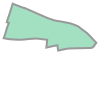

In [107]:
geom_highest = max_rows_df.geometry.iloc[0]
geom_highest

In [108]:
# Extract the network with the highest ward:
G_highest = ox.graph_from_polygon(
    geom_highest,
    simplify=True)

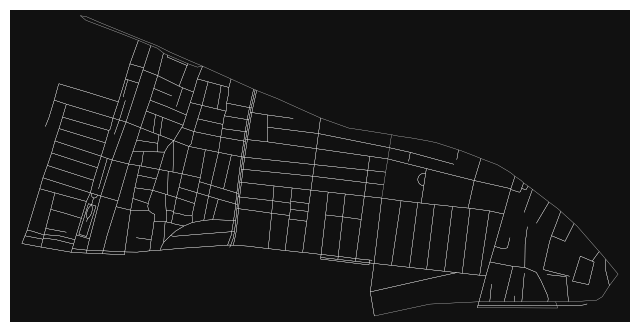

In [109]:
fig, ax = ox.plot_graph(G_highest, node_size=0, edge_color="w", edge_linewidth=0.2)

In [110]:
# Find the index label of the row with the maximum value in column 'C'
mask = df_merged['straightness'] == df_merged['straightness'].min()

# Apply the mask to the DataFrame
min_rows_df = df_merged[mask]

print(min_rows_df)

    ward_id      ward_name Corporatio  \
224      31  31 - Kadugodi       East   

                                              geometry  straightness  
224  POLYGON ((77.75824 12.98249, 77.75786 12.98247...      0.563037  


In [111]:
print(f'The ward with the lowest straightness is {min_rows_df["ward_name"]}')

The ward with the lowest straightness is 224    31 - Kadugodi
Name: ward_name, dtype: object


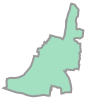

In [112]:
geom_lowest = min_rows_df.geometry.iloc[0]
geom_lowest

In [115]:
# Extract the network with the highest ward:
G_lowest = ox.graph_from_polygon(
    geom_lowest,
    simplify=True)

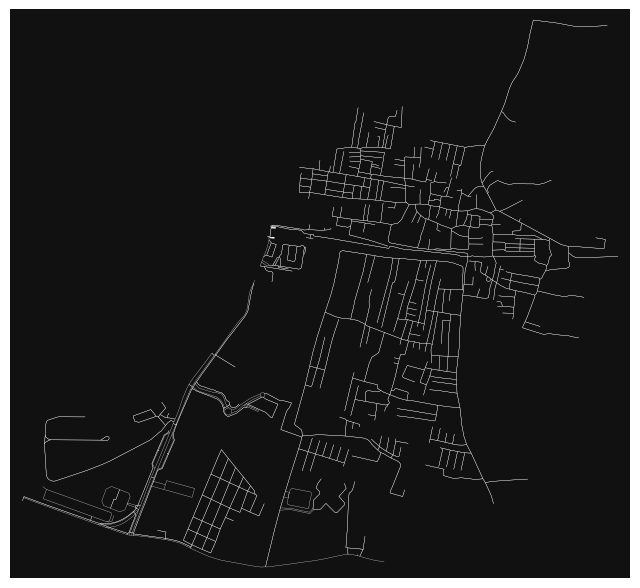

In [116]:
fig, ax = ox.plot_graph(G_lowest, node_size=0, edge_color="w", edge_linewidth=0.2)

In [117]:
G_clipped_lowest = ox.truncate.truncate_graph_polygon(G, geom_lowest)

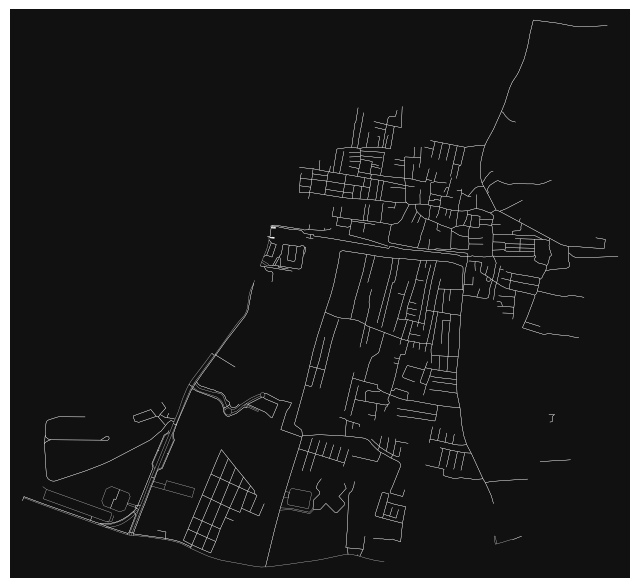

In [118]:
fig, ax = ox.plot_graph(G_clipped_lowest, node_size=0, edge_color="w", edge_linewidth=0.2)

Plot the straightness at the wards:

In [120]:
## Path to save the figure:
fig_path = IMAGES_DIR / 'straightness_all_roads_bangalore.png'

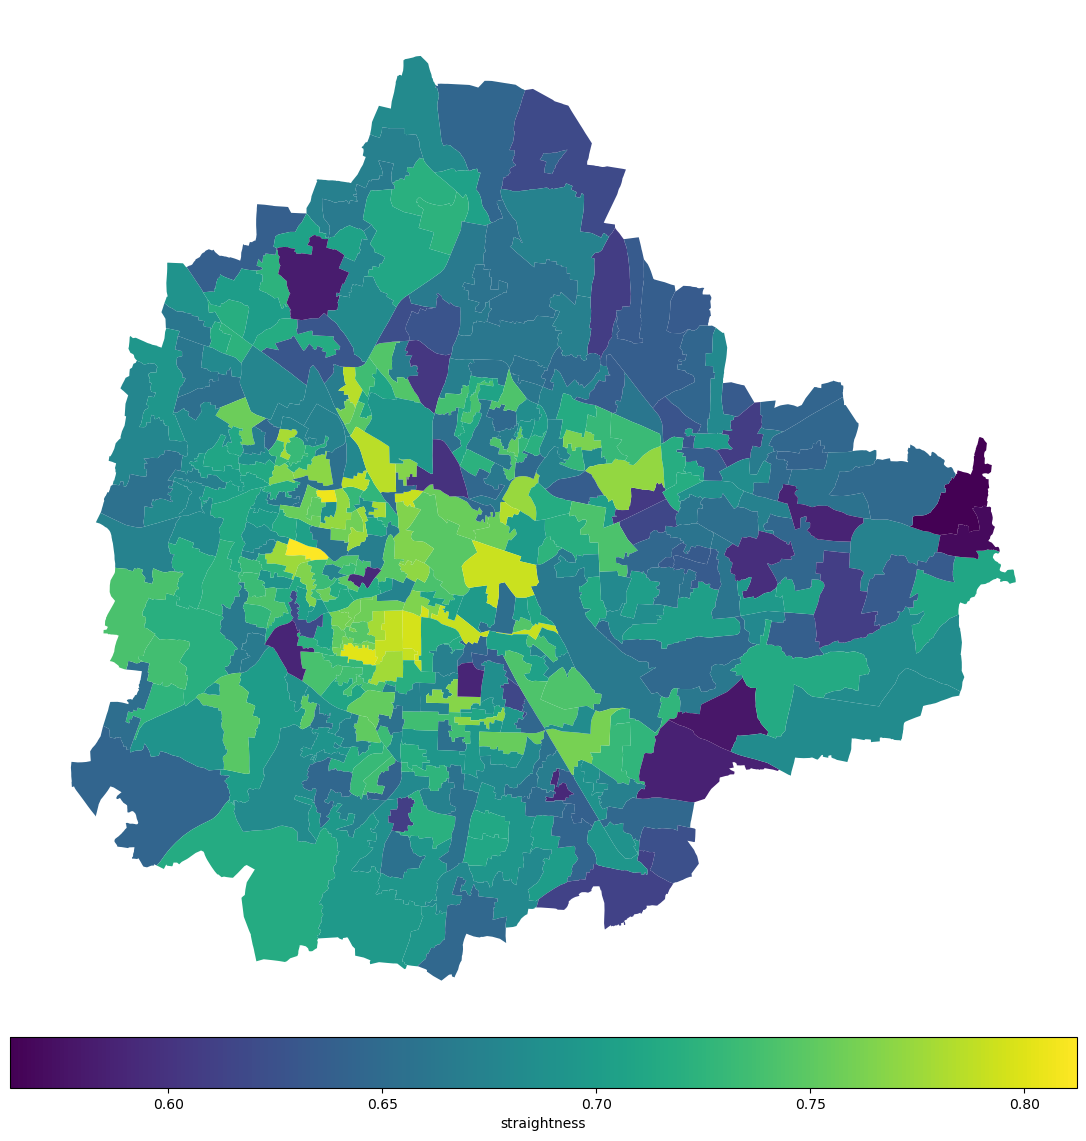

In [122]:
import matplotlib.pyplot as plt

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(1, 1, figsize=(14, 14))

divider = make_axes_locatable(ax)

cax = divider.append_axes("bottom", size="5%", pad=0.1)

df_merged.plot(
    column="straightness",
    ax=ax,
    legend=True,
    cax=cax,
    legend_kwds={"label": "straightness", "orientation": "horizontal"},
)
ax.set_axis_off()
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

plt.show()